# Setting Up Python Environment

In [ ]:
%%capture
# Install PyTorch with CUDA
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Install additional dependencies
!pip install matplotlib pandas pillow torchtnt==0.2.0 tqdm tabulate

# Install package for creating visually distinct colormaps
!pip install distinctipy

# Install utility packages
!pip install cjm_pandas_utils cjm_psl_utils cjm_pil_utils cjm_pytorch_utils cjm_torchvision_tfms

# Install torchmetrics
!pip install torchmetrics

# Importing the Required Dependencies

In [ ]:
# Import Python Standard Library dependencies
import datetime
from functools import partial
from glob import glob
import json
import math
import multiprocessing
import os
from pathlib import Path
import random
from typing import Any, Dict, Optional

# Import utility functions
from cjm_psl_utils.core import download_file, file_extract, get_source_code
from cjm_pil_utils.core import resize_img, get_img_files, stack_imgs
from cjm_pytorch_utils.core import pil_to_tensor, tensor_to_pil, get_torch_device, set_seed, denorm_img_tensor, move_data_to_device
from cjm_pandas_utils.core import markdown_to_pandas, convert_to_numeric, convert_to_string
from cjm_torchvision_tfms.core import ResizeMax, PadSquare, CustomRandomIoUCrop

# Import the distinctipy module
from distinctipy import distinctipy

# Import matplotlib for creating plots
import matplotlib.pyplot as plt

# Import numpy
import numpy as np

# Import the pandas package
import pandas as pd

# Set options for Pandas DataFrame display
pd.set_option('max_colwidth', None)  # Do not truncate the contents of cells in the DataFrame
pd.set_option('display.max_rows', None)  # Display all rows in the DataFrame
pd.set_option('display.max_columns', None)  # Display all columns in the DataFrame

# Import PIL for image manipulation
from PIL import Image, ImageDraw

# Import PyTorch dependencies
import torch
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchtnt.utils import get_module_summary
import torchvision
torchvision.disable_beta_transforms_warning()
from torchvision.tv_tensors import BoundingBoxes, Mask
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
from torchvision.transforms import v2 as transforms
from torchvision.transforms.v2 import functional as TF

# Import Mask R-CNN
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# Import tqdm for progress bar
from tqdm.auto import tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Setting Up the Project

## Setting a Random Number Seed

In [ ]:
# Set the seed for generating random numbers in PyTorch, NumPy, and Python's random module.
seed = 1234
set_seed(seed)

## Setting the Device and Data Type

In [ ]:
device = get_torch_device()
dtype = torch.float32
device, dtype

('cuda', torch.float32)

## Loading and Exploring the Dataset

### Setting the Dataset Path

In [ ]:
dataset_path = Path(f'/content/drive/MyDrive/DL_project/dataset/')

In [ ]:
dataset_path

PosixPath('/content/drive/MyDrive/DL_project/dataset')

### Getting the Image and Annotation Files

In [ ]:
# Get a list of image files in the dataset
img_file_paths = get_img_files(dataset_path)

# Get a list of JSON files in the dataset
annotation_file_paths = list(dataset_path.glob('*.json'))

# Display the names of the folders using a Pandas DataFrame
pd.DataFrame({"Image File": [file.name for file in img_file_paths],
              "Annotation File":[file.name for file in annotation_file_paths]}).head()

,Image File,Annotation File
0,00001.jpg,00049.json
1,00006.jpg,00046.json
2,00008.jpg,00005.json
3,00009.jpg,00042.json
4,00004.jpg,00015.json


### Get Image File Paths

In [ ]:
# Create a dictionary that maps file names to file paths
img_dict = {file.stem : file for file in img_file_paths}

# Print the number of image files
print(f"Number of Images: {len(img_dict)}")

# Display the first five entries from the dictionary using a Pandas DataFrame
pd.DataFrame.from_dict(img_dict, orient='index').head()

Number of Images: 205


,0
00001,/content/drive/MyDrive/DL_project/dataset/00001.jpg
00006,/content/drive/MyDrive/DL_project/dataset/00006.jpg
00008,/content/drive/MyDrive/DL_project/dataset/00008.jpg
00009,/content/drive/MyDrive/DL_project/dataset/00009.jpg
00004,/content/drive/MyDrive/DL_project/dataset/00004.jpg


### Get Image Annotations

In [ ]:
# import os
# import json
# import pandas as pd
# from tqdm import tqdm

# annotation_file_paths: iterable of paths to the per-image JSON files
rows = []

for f in tqdm(annotation_file_paths):
    with open(f, "r") as fp:
        data = json.load(fp)

    # flatten top-level fields
    row = {
        "key": data.get("key"),
        "height": data.get("height"),
        "width": data.get("width"),
        "boxes": data.get("boxes", []),
    }
    rows.append(row)

annotation_df = pd.DataFrame(rows)

# Use "key" (e.g. "00001.jpg") to derive index name like "00001"
annotation_df["index"] = annotation_df["key"].apply(
    lambda v: os.path.splitext(os.path.basename(v))[0] if pd.notna(v) else None
)
annotation_df = annotation_df.set_index("index")

# Keep only rows whose index exists in img_dict
annotation_df = annotation_df.loc[annotation_df.index.intersection(img_dict.keys())]

# Peek
annotation_df.head()


  0%|          | 0/205 [00:00<?, ?it/s]

key  height  width  \
index                             
00049  00049.jpg    5712   4284   
00046  00046.jpg    5712   4284   
00005  00005.jpg    5712   4284   
00042  00042.jpg    5712   4284   
00015  00015.jpg    5712   4284   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

### Inspecting the Class Distribution

#### Get image classes

In [ ]:
# Explode the 'boxes' column in the annotation_df dataframe
# Convert the resulting series to a dataframe and rename the 'boxes' column to 'boxes'

# Explode the 'boxes' column so each row corresponds to one polygon object
boxes_df = annotation_df['boxes'].explode().to_frame().boxes.apply(pd.Series)

# Extract unique class names actually present
class_names = sorted(boxes_df['label'].unique().tolist())

pd.DataFrame(class_names, columns=["class_name"])


,class_name
0,pen
1,plug
2,shoe


In [ ]:
# Get a list of unique labels in the 'annotation_df' DataFrame
class_counts = boxes_df['label'].value_counts()

class_counts


,count
label,
shoe,607
pen,478
plug,379


#### Visualize the class distribution

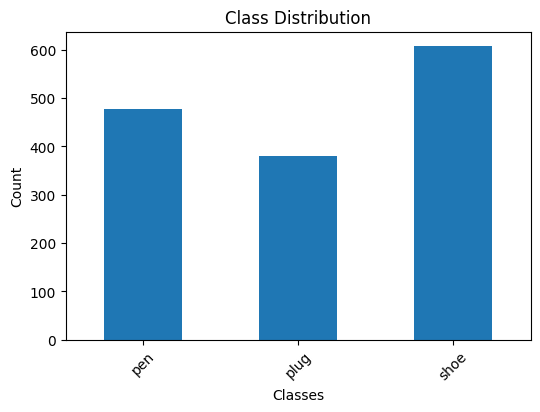

In [ ]:
# Explode annotation_df['boxes'] so each row = 1 polygon annotation
boxes_df = annotation_df['boxes'].explode().to_frame().boxes.apply(pd.Series)

# Count classes
class_counts = boxes_df['label'].value_counts().sort_index()

# Plot
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')

plt.title('Class Distribution')
plt.ylabel('Count')
plt.xlabel('Classes')
plt.xticks(rotation=45)

plt.show()


#### Add a background class

In [ ]:
# # Prepend a `background` class to the list of class names
class_names = ['background']+class_names

# # Display labels using a Pandas DataFrame
pd.DataFrame(class_names)

,0
0,background
1,pen
2,plug
3,shoe


### Visualizing Image Annotations

#### Generate a color map

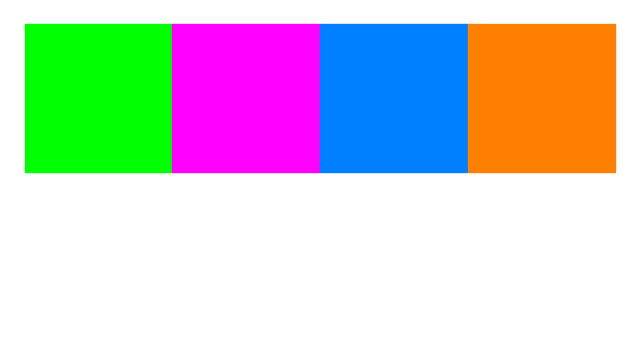

In [ ]:
# Generate a list of colors with a length equal to the number of labels
colors = distinctipy.get_colors(len(class_names))

# Make a copy of the color map in integer format
int_colors = [tuple(int(c*255) for c in color) for color in colors]

# Generate a color swatch to visualize the color map
distinctipy.color_swatch(colors)

#### Download a font file

In [ ]:
# Set the name of the font file
font_file = 'KFOlCnqEu92Fr1MmEU9vAw.ttf'

# Download the font file
download_file(f"https://fonts.gstatic.com/s/roboto/v30/{font_file}", "./")

  0%|          | 0.00/130k [00:00<?, ?iB/s]

#### Define the bounding box annotation function

In [ ]:
draw_bboxes = partial(draw_bounding_boxes, fill=False, width=2, font=font_file, font_size=25)

### Selecting a Sample Image

#### Load the sample image

In [ ]:
# Get the file ID of the first image file
file_id = list(img_dict.keys())[1]

# Open the associated image file as a RGB image
sample_img = Image.open(img_dict[file_id]).convert('RGB')

# Print the dimensions of the image
print(f"Image Dims: {sample_img.size}")
print(f"Image name: {file_id}")
# Show the image
sample_img

Output hidden; open in https://colab.research.google.com to view.

#### Inspect the corresponding annotation data

In [ ]:
# # Get the row from the 'annotation_df' DataFrame corresponding to the 'file_id'
annotation_df.loc[[file_id]]


key  height  width  \
index                             
00006  00006.jpg    5712   4284   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

#### Define a function to convert segmentation polygons to images

In [ ]:
def create_polygon_mask(image_size, vertices):
    """
    Create a grayscale image with a white polygonal area on a black background.

    Parameters:
    - image_size (tuple): A tuple representing the dimensions (width, height) of the image.
    - vertices (list): A list of tuples, each containing the x, y coordinates of a vertex
                        of the polygon. Vertices should be in clockwise or counter-clockwise order.

    Returns:
    - PIL.Image.Image: A PIL Image object containing the polygonal mask.
    """

    # Create a new black image with the given dimensions
    mask_img = Image.new('L', image_size, 0)

    # Draw the polygon on the image. The area inside the polygon will be white (255).
    ImageDraw.Draw(mask_img, 'L').polygon(vertices, fill=(255))

    # Return the image with the drawn polygon
    return mask_img

#### Annotate sample image

In [ ]:
# from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
# from torchvision import transforms

# 1) Get annotation row for this image
row = annotation_df.loc[file_id]

# 2) Extract labels and polygon points from 'boxes'
labels = [box["label"] for box in row["boxes"]]
shape_points = [box["points"] for box in row["boxes"]]

# 3) Format polygon points for PIL (list of (x, y) tuples, ints)
xy_coords = [
    [tuple(map(int, p)) for p in points]   # each 'points' is a list [[x,y], ...]
    for points in shape_points
]

# 4) Generate mask images from polygons
mask_imgs = [create_polygon_mask(sample_img.size, xy) for xy in xy_coords]

# 5) Convert mask images to boolean tensors of shape (N, H, W)
mask_tensors = [
    transforms.PILToTensor()(mask_img).squeeze(0).bool()  # (1,H,W) -> (H,W)
    for mask_img in mask_imgs
]
masks = torch.stack(mask_tensors, dim=0)  # (N,H,W)

# 6) Generate bounding boxes from masks
bboxes = torchvision.ops.masks_to_boxes(masks)  # (N,4) in xyxy

# 7) Base image as tensor (C,H,W)
img_tensor = transforms.PILToTensor()(sample_img)

# 8) Colors per label (using the class_names + int_colors, with background at index 0)
label_indices = [class_names.index(label) for label in labels]
# colors_for_labels = [int_colors[i] for i in label_indices]
# After we have class_names and int_colors:
label_to_color = {
    name: int_colors[i]
    for i, name in enumerate(class_names)
}

# For current image:
colors_for_labels = [label_to_color[label] for label in labels]

# 9) Draw segmentation masks
annotated_tensor = draw_segmentation_masks(
    image=img_tensor,
    masks=masks,
    alpha=0.3,
    colors=colors_for_labels,
)

# 10) Draw bounding boxes + labels
annotated_tensor = draw_bounding_boxes(
    image=annotated_tensor,
    boxes=bboxes,
    labels=labels,
    colors=colors_for_labels,
)

# 11) Convert back to PIL for display
annotated_img = transforms.ToPILImage()(annotated_tensor)
annotated_img


Output hidden; open in https://colab.research.google.com to view.

## Loading the Mask R-CNN Model

In [ ]:
# Initialize a Mask R-CNN model with pretrained weights
model = maskrcnn_resnet50_fpn_v2(weights='DEFAULT')

# Get the number of input features for the classifier
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels

# Get the numbner of output channels for the Mask Predictor
dim_reduced = model.roi_heads.mask_predictor.conv5_mask.out_channels

# Replace the box predictor
model.roi_heads.box_predictor = FastRCNNPredictor(in_channels=in_features_box, num_classes=len(class_names))

# Replace the mask predictor
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_channels=in_features_mask, dim_reduced=dim_reduced, num_classes=len(class_names))

# Set the model's device and data type
model.to(device=device, dtype=dtype);

# Add attributes to store the device and model name for later reference
model.device = device
model.name = 'maskrcnn_resnet50_fpn_v2'

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:00<00:00, 239MB/s]


In [ ]:
box_head = model.roi_heads.box_predictor
print(box_head)


FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=4, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=16, bias=True)
)


Number of classes are three i.e. shoe, pen, and plug. Mask R-CNN's box head predicts 4 numbers per class. Each object class need 4 bounding-box values: $x_1, y_1, x_2, y_2$ so, the output features for box is 12.

### Summarizing the Model

In [ ]:
test_inp = torch.randn(1, 3, 256, 256).to(device)

summary_df = markdown_to_pandas(f"{get_module_summary(model.eval(), [test_inp])}")

# # Filter the summary to only contain Conv2d layers and the model
summary_df = summary_df[summary_df.index == 0]

summary_df.drop(['In size', 'Out size', 'Contains Uninitialized Parameters?'], axis=1)

/usr/local/lib/python3.12/dist-packages/torchtnt/utils/module_summary.py:271: UserWarning: Backward FLOPs are only computed if module foward returns a tensor.
  warnings.warn(


,Type,# Parameters,# Trainable Parameters,Size (bytes),Forward FLOPs
0,MaskRCNN,45.9 M,45.7 M,183 M,331 G


## Preparing the Data

### Training-Validation-Test Split

In [ ]:
# Get the list of image IDs
img_keys = list(img_dict.keys())

# Shuffle the keys
random.shuffle(img_keys)

# Define split percentages
train_pct = 0.8
val_pct   = 0.1
test_pct  = 0.1   # val + test = 20%

# Total number of images
n = len(img_keys)

# Compute split indices
train_end = int(n * train_pct)
val_end   = int(n * (train_pct + val_pct))

# Split into train, val, test
train_keys = img_keys[:train_end]
val_keys   = img_keys[train_end:val_end]
test_keys  = img_keys[val_end:]

# Display summary
pd.Series({
    "Training Samples":   len(train_keys),
    "Validation Samples": len(val_keys),
    "Test Samples":       len(test_keys),
}).to_frame().style.hide(axis='columns')


Training Samples,164
Validation Samples,20
Test Samples,21


### Data Augmentation

#### Set training image size

In [ ]:
# Set training image size
train_sz = 512

#### Initialize the transforms

In [ ]:
# Create a RandomIoUCrop object
iou_crop = CustomRandomIoUCrop(min_scale=0.3,
                               max_scale=1.0,
                               min_aspect_ratio=0.5,
                               max_aspect_ratio=2.0,
                               sampler_options=[0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                               trials=400,
                               jitter_factor=0.25)

In [ ]:
# Create a `ResizeMax` object
resize_max = ResizeMax(max_sz=train_sz)

# Create a `PadSquare` object
pad_square = PadSquare(shift=True, fill=0)

#### Test the transforms

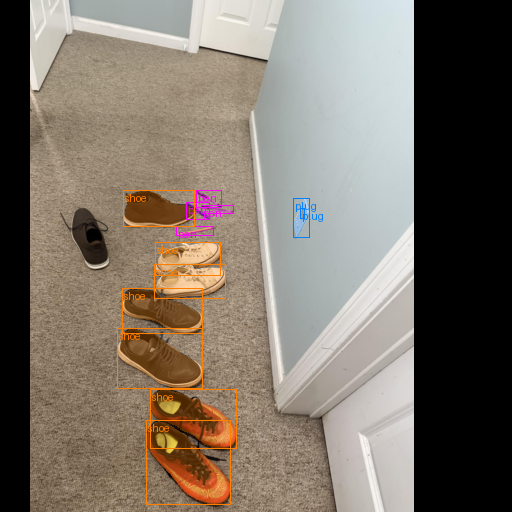

Source Image:,"(4284, 5712)"
Cropped Image:,"(4284, 5712)"
Resized Image:,"(384, 512)"
Padded Image:,"(512, 512)"
Resized Padded Image:,"(512, 512)"


In [ ]:
# import torch
# import torchvision
# # from torchvision import transforms
# # from torchvision.transforms import v2 as T
# from torchvision.transforms import v2 as transforms
# from torchvision.tv_tensors import Mask, BoundingBoxes
# from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes

# 1) Build masks, boxes, labels

row = annotation_df.loc[file_id]

# Extract labels and polygon points from 'boxes'
labels = [box["label"] for box in row["boxes"]]
shape_points = [box["points"] for box in row["boxes"]]

# Format polygon points for PIL: list of (x, y) int tuples
xy_coords = [
    [ (int(x), int(y)) for (x, y) in points ]
    for points in shape_points
]

# Generate mask images from polygons
mask_imgs = [create_polygon_mask(sample_img.size, xy) for xy in xy_coords]

# Convert mask images to boolean tensors of shape (N, H, W)
mask_tensors = [
    transforms.PILToTensor()(mask_img).squeeze(0).bool()  # (1,H,W) -> (H,W)
    for mask_img in mask_imgs
]

if len(mask_tensors) == 0:
    raise ValueError(f"No masks for image {file_id}")

masks = torch.stack(mask_tensors, dim=0)  # (N, H, W)

# Generate bounding box annotations from segmentation masks
boxes_xyxy = torchvision.ops.masks_to_boxes(masks)  # (N, 4)

bboxes = BoundingBoxes(
    data=boxes_xyxy,
    format="xyxy",
    canvas_size=(sample_img.height, sample_img.width),  # (H, W)
)

# Prepare mask and bounding box targets
targets = {
    "masks": Mask(masks),
    "boxes": bboxes,
    "labels": torch.tensor(
        [class_names.index(label) for label in labels],
        dtype=torch.int64,
    )
}

# 2) Apply augmentations

# Crop the image
cropped_img, targets = iou_crop(sample_img, targets)

# Resize the image (custom ResizeMax)
resized_img, targets = resize_max(cropped_img, targets)

# Pad the image (custom PadSquare)
padded_img, targets = pad_square(resized_img, targets)

# Ensure the padded image is the target size using v2.Resize
resize = transforms.Resize([train_sz, train_sz], antialias=True)
resized_padded_img, targets = resize(padded_img, targets)

# Remove degenerate boxes after all resizing
sanitize = transforms.SanitizeBoundingBoxes()
sanitized_img, targets = sanitize(resized_padded_img, targets)

# 3) Prepare colors after aug

# Recompute labels and colors after augmentations (objects can be dropped)
final_label_indices = targets["labels"]           # tensor of indices into class_names
final_labels = [class_names[int(i)] for i in final_label_indices]

# Map each label index to its color
colors_for_labels = [int_colors[int(i)] for i in final_label_indices]

# 4) Draw masks + boxes

img_tensor = transforms.PILToTensor()(sanitized_img)

# Annotate the sample image with segmentation masks
annotated_tensor = draw_segmentation_masks(
    image=img_tensor,
    masks=targets["masks"],   # (N, H, W) bool
    alpha=0.3,
    colors=colors_for_labels,
)

# Annotate the sample image with labels and bounding boxes
annotated_tensor = draw_bounding_boxes(
    image=annotated_tensor,
    boxes=targets["boxes"],
    labels=final_labels,
    colors=colors_for_labels,
)

# Display the annotated image
display(transforms.ToPILImage()(annotated_tensor))

# 5) Show size changes

pd.Series({
    "Source Image:": sample_img.size,
    "Cropped Image:": cropped_img.size,
    "Resized Image:": resized_img.size,
    "Padded Image:": padded_img.size,
    "Resized Padded Image:": sanitized_img.size,
}).to_frame().style.hide(axis="columns")


### Training Dataset Class

In [ ]:
# import torch
# from torch.utils.data import Dataset
# from PIL import Image
# from torchvision import transforms
# from torchvision.tv_tensors import Mask, BoundingBoxes
# import torchvision

class SPPDataset(Dataset):
    """
    PyTorch Dataset for images and their annotations (instance segmentation).

    Expects:
    - annotation_df index: image key (e.g., '00001')
    - annotation_df['boxes']: list of dicts with keys:
        - 'label': class name (e.g., 'shoe', 'pen', 'plug')
        - 'points': list of [x, y] polygon vertices
    - img_dict: {image_key -> image_path}
    """

    def __init__(self, img_keys, annotation_df, img_dict, class_to_idx, transforms=None):
        super().__init__()

        self._img_keys = img_keys              # list of image keys (must match annotation_df index)
        self._annotation_df = annotation_df    # DataFrame with 'boxes' column
        self._img_dict = img_dict              # {key: filepath}
        self._class_to_idx = class_to_idx      # {'background':0, 'plug':1, 'pen':2, 'shoe':3, ...}
        self._transforms = transforms          # callable(image, target) -> (image, target)

    def __len__(self):
        return len(self._img_keys)

    def __getitem__(self, index):
        # 1) get key for this sample
        img_key = self._img_keys[index]

        # 2) get annotations for this key (Series)
        annotation = self._annotation_df.loc[img_key]

        # 3) load image + target dict
        image, target = self._load_image_and_target(annotation)

        # 4) apply joint transforms if provided
        if self._transforms is not None:
            image, target = self._transforms(image, target)

        return image, target

    def _load_image_and_target(self, annotation):
        """
        Load an image and its target (masks, boxes, labels) for Mask R-CNN.
        """
        # --- image ---
        filepath = self._img_dict[annotation.name]   # annotation.name is the img_key / index
        image = Image.open(filepath).convert("RGB")

        # --- labels ---
        boxes_info = annotation["boxes"]            # list of dicts: {'label':..., 'points':...}
        labels_str = [box["label"] for box in boxes_info]
        labels = torch.tensor(
            [self._class_to_idx[label] for label in labels_str],
            dtype=torch.int64
        )

        # --- polygons -> masks ---
        # each box["points"] is [[x, y], ...]
        shape_points = [box["points"] for box in boxes_info]
        xy_coords = [
            [ (int(x), int(y)) for (x, y) in pts ]
            for pts in shape_points
        ]

        # create a mask image per polygon
        mask_imgs = [create_polygon_mask(image.size, xy) for xy in xy_coords]

        # convert each to (H, W) bool tensor
        mask_tensors = [
            transforms.PILToTensor()(m).squeeze(0).bool()   # (1,H,W) -> (H,W)
            for m in mask_imgs
        ]

        if len(mask_tensors) == 0:
            # no objects in this image
            masks = Mask(torch.zeros((0, image.height, image.width), dtype=torch.bool))
            boxes_xyxy = torch.zeros((0, 4), dtype=torch.float32)
        else:
            masks = Mask(torch.stack(mask_tensors, dim=0))          # (N, H, W)
            boxes_xyxy = torchvision.ops.masks_to_boxes(masks)      # (N, 4)

        # --- bounding boxes tv_tensor ---
        bboxes = BoundingBoxes(
            data=boxes_xyxy,
            format="xyxy",
            canvas_size=(image.height, image.width)  # (H, W)
        )

        target = {
            "masks": masks,      # tv_tensors.Mask (N, H, W)
            "boxes": bboxes,     # tv_tensors.BoundingBoxes (N, 4)
            "labels": labels,    # Tensor (N,)
        }

        return image, target


### Image Transforms

In [ ]:
# from torchvision.transforms import v2 as T

# 1) Data augmentation (only for train)
data_aug_tfms = transforms.Compose([
    iou_crop,  # CustomRandomIoUCrop that accepts (img, target)

    transforms.ColorJitter(
        brightness=(0.7, 1.3),
        contrast=(0.5, 1.8),
        saturation=(0.5, 1.8),
        hue=(-0.1, 0.1),
    ),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomAutocontrast(p=0.3),
    transforms.RandomPosterize(bits=3, p=0.5),
    transforms.RandomEqualize(p=0.3),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=(-10, 10)),

    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5)),

    transforms.RandomErasing(
        p=0.5,
        scale=(0.01, 0.05),
        ratio=(0.3, 3.3),
        value="random",
    ),
])

# 2) Resize + pad
resize_pad_tfm = transforms.Compose([
    resize_max,                       # custom v2-compatible transform
    pad_square,                       # custom v2-compatible transform
    transforms.Resize([train_sz] * 2, antialias=True),
])

# 3) Final conversions
final_tfms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    transforms.SanitizeBoundingBoxes(),
])

# 4) Full pipelines
train_tfms = transforms.Compose([
    data_aug_tfms,
    resize_pad_tfm,
    final_tfms,
])

valid_tfms = transforms.Compose([
    resize_pad_tfm,
    final_tfms,
])


### Initialize Datasets

In [ ]:
# Create a mapping from class names to class indices
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Instantiate datasets using the defined transforms
train_dataset = SPPDataset(train_keys, annotation_df, img_dict, class_to_idx, train_tfms)
valid_dataset = SPPDataset(val_keys,  annotation_df, img_dict, class_to_idx, valid_tfms)
test_dataset  = SPPDataset(test_keys,  annotation_df, img_dict, class_to_idx, valid_tfms)   # test uses no augmentation

# Print dataset sizes
pd.Series({
    'Training dataset size':   len(train_dataset),
    'Validation dataset size': len(valid_dataset),
    'Test dataset size':       len(test_dataset),
}).to_frame().style.hide(axis='columns')


Training dataset size,164
Validation dataset size,20
Test dataset size,21


### Inspect Samples

#### Inspect training set sample

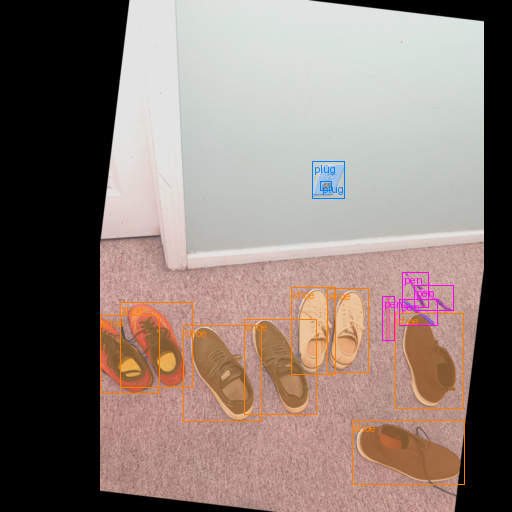

In [ ]:
# from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
# from torchvision.transforms import v2 as T

# Take one sample from the training dataset
image, target = train_dataset[0]

# image: float tensor in [0,1], shape (C, H, W)
# target: {'masks': Mask(N,H,W), 'boxes': BoundingBoxes(N,4), 'labels': Tensor(N,)}

# Convert image to uint8 for visualization
img_vis = (image * 255).to(torch.uint8)

# Extract masks, boxes, labels
masks = target["masks"]          # tv_tensors.Mask, (N,H,W), bool
boxes = target["boxes"]          # tv_tensors.BoundingBoxes, (N,4)
labels_idx = target["labels"]    # Tensor(N,), int64 indices into class_names

# Map labels -> colors
sample_colors = [int_colors[int(i)] for i in labels_idx]
sample_labels = [class_names[int(i)] for i in labels_idx]

# Draw segmentation masks
annotated_tensor = draw_segmentation_masks(
    image=img_vis,
    masks=masks,
    alpha=0.3,
    colors=sample_colors,
)

# Draw bounding boxes + labels
annotated_tensor = draw_bounding_boxes(
    image=annotated_tensor,
    boxes=boxes.as_subclass(torch.Tensor),  # ensure plain Tensor for safety
    labels=sample_labels,
    colors=sample_colors,
)

# Convert back to PIL for display
annotated_img = transforms.ToPILImage()(annotated_tensor)
annotated_img


#### Inspect validation set sample

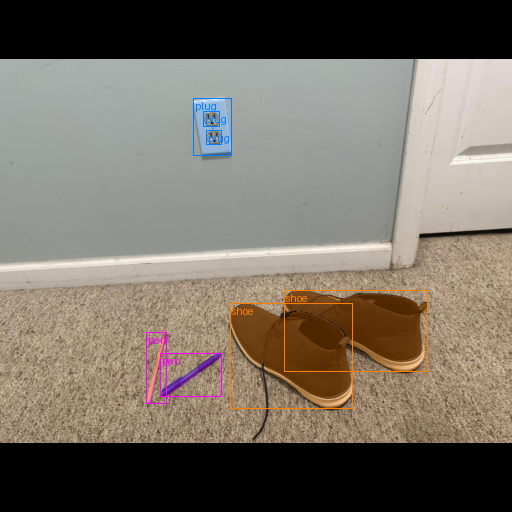

In [ ]:
# from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
# from torchvision import transforms as T

# Get one sample from the validation dataset
image, target = valid_dataset[0]

# Convert float image [0,1] -> uint8 tensor
img_vis = (image * 255).to(torch.uint8)

# Extract masks, boxes, labels
masks = target["masks"]            # tv_tensor: (N, H, W)
boxes = target["boxes"]            # tv_tensor: (N, 4)
labels_idx = target["labels"]      # Tensor(N,), int64

# Map labels to colors & names
sample_colors = [int_colors[int(i)] for i in labels_idx]
sample_labels = [class_names[int(i)] for i in labels_idx]

# Draw segmentation masks
annotated_tensor = draw_segmentation_masks(
    image=img_vis,
    masks=masks,
    alpha=0.3,
    colors=sample_colors
)

# Draw bounding boxes + labels
annotated_tensor = draw_bounding_boxes(
    image=annotated_tensor,
    boxes=boxes.as_subclass(torch.Tensor),   # convert tv_tensor -> plain tensor
    labels=sample_labels,
    colors=sample_colors
)

# Convert result to PIL
annotated_img = transforms.ToPILImage()(annotated_tensor)
annotated_img


### Initialize DataLoaders

In [ ]:
# Set the training batch size
bs = 8

# Set the number of worker processes for loading data.
# num_workers = multiprocessing.cpu_count()//2
num_workers = 0
# Define parameters for DataLoader
data_loader_params = {
    'batch_size': bs,  # Batch size for data loading
    'num_workers': num_workers,  # Number of subprocesses to use for data loading
    'persistent_workers': False,  # If True, the data loader will not shutdown the worker processes after a dataset has been consumed once. This allows to maintain the worker dataset instances alive.
    'pin_memory': 'cuda' in device,  # If True, the data loader will copy Tensors into CUDA pinned memory before returning them. Useful when using GPU.
    'pin_memory_device': device if 'cuda' in device else '',  # Specifies the device where the data should be loaded. Commonly set to use the GPU.
    'collate_fn': lambda batch: tuple(zip(*batch)),
}
# Create DataLoader for training data. Data is shuffled for every epoch.
train_dataloader = DataLoader(train_dataset, **data_loader_params, shuffle=True)

# Create DataLoader for validation data. Shuffling is not necessary for validation data.
valid_dataloader = DataLoader(valid_dataset, **data_loader_params)

# Create DataLoader for test data. Shuffling is not necessary for test data.
test_dataloader = DataLoader(test_dataset, **data_loader_params)
# Print the number of batches in the training, validation, and test  DataLoaders
pd.Series({
    'Number of batches in train DataLoader:': len(train_dataloader),
    'Number of batches in validation DataLoader:': len(valid_dataloader),
    'Number of batches in test DataLoader:': len(test_dataloader)}
).to_frame().style.hide(axis='columns')

Number of batches in train DataLoader:,21
Number of batches in validation DataLoader:,3
Number of batches in test DataLoader:,3


In [ ]:
# Standard collate for detection/segmentation models
def collate_fn(batch):
    return tuple(zip(*batch))


In [ ]:
def move_targets_to_device(targets, device):
    """
    targets: list[dict] from DataLoader
    returns: new list with boxes, masks, labels moved to device
    """
    new_targets = []
    for t in targets:
        new_t = {
            "boxes": t["boxes"].to(device),
            "masks": t["masks"].to(device),
            "labels": t["labels"].to(device),
        }
        new_targets.append(new_t)
    return new_targets


In [ ]:
# Evaluation DataLoaders (bs = 8)
eval_bs = 8
num_workers = 0

eval_loader_params = {
    "batch_size": eval_bs,
    "num_workers": num_workers,
    "persistent_workers": False,
    "pin_memory": ("cuda" in device),
    "pin_memory_device": device if ("cuda" in device) else "",
    "collate_fn": collate_fn,
}

train_eval_loader = DataLoader(train_dataset, shuffle=False, **eval_loader_params)
valid_eval_loader = DataLoader(valid_dataset, shuffle=False, **eval_loader_params)
test_eval_loader = DataLoader(test_dataset, shuffle=False, **eval_loader_params)

Mask IoU matrix utility

In [ ]:
def mask_iou_matrix(pred_masks, gt_masks):
    """
    pred_masks: (Np, H, W) bool
    gt_masks:   (Ng, H, W) bool
    returns: (Np, Ng) IoU matrix
    """
    if pred_masks.numel() == 0 or gt_masks.numel() == 0:
        return torch.zeros((pred_masks.shape[0], gt_masks.shape[0]), dtype=torch.float32)

    pred_flat = pred_masks.flatten(1).float()  # (Np, H*W)
    gt_flat   = gt_masks.flatten(1).float()    # (Ng, H*W)

    inter = pred_flat @ gt_flat.T              # (Np, Ng)
    pred_area = pred_flat.sum(1, keepdim=True) # (Np,1)
    gt_area   = gt_flat.sum(1, keepdim=True).T # (1,Ng)

    union = pred_area + gt_area - inter
    iou = inter / union.clamp(min=1e-6)
    return iou


mAP + IoU evaluator for instance segmentation

In [ ]:
@torch.no_grad()
def evaluate_instance_segmentation_mAP(
    model,
    dataloader,
    device,
    class_names,
    iou_thresh=0.5,
    score_thresh=0.0
):
    model.eval()

    num_classes = len(class_names)
    foreground_classes = list(range(0, num_classes))

    # Collect per-class stats
    class_pred_scores = {c: [] for c in foreground_classes}
    class_pred_tp = {c: [] for c in foreground_classes}
    class_num_gt = {c: 0 for c in foreground_classes}
    class_tp_iou_sum = {c: 0.0 for c in foreground_classes}

    for images, targets in tqdm(dataloader, desc="Eval mAP/IoU"):
        # Move images
        images_dev = [img.to(device) for img in images]

        # Move GT
        gt_masks_list = []
        gt_labels_list = []
        for t in targets:
            gt_masks_list.append(t["masks"].to(device))   # (Ng,H,W)
            gt_labels_list.append(t["labels"].to(device)) # (Ng,)

        # Predictions
        outputs = model(images_dev)

        for pred, gt_masks, gt_labels in zip(outputs, gt_masks_list, gt_labels_list):
            # count GT per class
            for c in foreground_classes:
                class_num_gt[c] += int((gt_labels == c).sum().item())

            # filter preds by score
            scores = pred["scores"].to(device)
            keep = scores >= score_thresh
            if keep.sum() == 0:
                continue

            pred_scores = scores[keep]
            pred_labels = pred["labels"][keep].to(device)
            pred_masks = pred["masks"][keep].to(device)   # (Np,1,H,W)
            pred_masks = (pred_masks.squeeze(1) >= 0.5)   # (Np,H,W) bool

            # Prepare GT by class
            gt_by_class = {}
            gt_used_by_class = {}
            for c in foreground_classes:
                cls_gt_mask = (gt_labels == c)
                gt_by_class[c] = gt_masks[cls_gt_mask]  # (Ng_c,H,W)
                gt_used_by_class[c] = torch.zeros(gt_by_class[c].shape[0], dtype=torch.bool, device=device)

            # Process per class
            for c in foreground_classes:
                cls_pred_mask = (pred_labels == c)
                if cls_pred_mask.sum() == 0:
                    continue

                cls_pred_scores = pred_scores[cls_pred_mask]
                cls_pred_masks  = pred_masks[cls_pred_mask]

                # sort by score
                sorted_idx = torch.argsort(cls_pred_scores, descending=True)
                cls_pred_scores = cls_pred_scores[sorted_idx]
                cls_pred_masks  = cls_pred_masks[sorted_idx]

                Ng = gt_by_class[c].shape[0]
                gt_used = gt_used_by_class[c]
                gt_masks_c = gt_by_class[c]

                # no GT of this class
                if Ng == 0:
                    class_pred_scores[c].extend(cls_pred_scores.cpu().tolist())
                    class_pred_tp[c].extend([0] * cls_pred_scores.shape[0])
                    continue

                ious = mask_iou_matrix(cls_pred_masks, gt_masks_c)  # (Np_c,Ng)

                for k in range(cls_pred_scores.shape[0]):
                    iou_row = ious[k]
                    best_iou, best_gt_idx = iou_row.max(dim=0)
                    best_iou_val = best_iou.item()
                    best_gt_idx = best_gt_idx.item()

                    class_pred_scores[c].append(cls_pred_scores[k].item())

                    if best_iou_val >= iou_thresh and not gt_used[best_gt_idx]:
                        class_pred_tp[c].append(1)
                        gt_used[best_gt_idx] = True
                        class_tp_iou_sum[c] += best_iou_val
                    else:
                        class_pred_tp[c].append(0)

    # AP helper
    def compute_ap_from_scores(scores, tps, num_gt):
        if num_gt == 0 or len(scores) == 0:
            return 0.0

        scores = torch.tensor(scores)
        tps = torch.tensor(tps).float()
        sorted_idx = torch.argsort(scores, descending=True)
        tps = tps[sorted_idx]
        fps = 1.0 - tps

        cum_tp = torch.cumsum(tps, dim=0)
        cum_fp = torch.cumsum(fps, dim=0)

        recalls = cum_tp / num_gt
        precisions = cum_tp / (cum_tp + cum_fp + 1e-6)

        mrec = torch.cat([torch.tensor([0.0]), recalls, torch.tensor([1.0])])
        mpre = torch.cat([torch.tensor([0.0]), precisions, torch.tensor([0.0])])

        for i in range(mpre.numel() - 1, 0, -1):
            mpre[i - 1] = torch.maximum(mpre[i - 1], mpre[i])

        idx = torch.where(mrec[1:] != mrec[:-1])[0]
        ap = torch.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]).item()
        return ap

    per_class_ap = {}
    per_class_mean_iou = {}
    ap_list = []

    for c in foreground_classes:
        ap_c = compute_ap_from_scores(
            class_pred_scores[c],
            class_pred_tp[c],
            class_num_gt[c],
        )
        per_class_ap[class_names[c]] = ap_c
        ap_list.append(ap_c)

        tp_count = sum(class_pred_tp[c])
        if tp_count > 0:
            per_class_mean_iou[class_names[c]] = class_tp_iou_sum[c] / tp_count
        else:
            per_class_mean_iou[class_names[c]] = 0.0

    mAP = sum(ap_list) / max(1, len(ap_list))
    mean_iou_all = sum(per_class_mean_iou.values()) / max(1, len(per_class_mean_iou))

    results = {
        f"mAP@{iou_thresh:.2f}": mAP,
        "per_class_AP": per_class_ap,
        "per_class_mean_IoU": per_class_mean_iou,
        "mean_IoU_TP": mean_iou_all,
        "iou_thresh": iou_thresh,
        "score_thresh": score_thresh,
    }
    return results


Run baseline mAP + IoU

In [ ]:
train_seg_metrics = evaluate_instance_segmentation_mAP(
    model, train_eval_loader, device, class_names, iou_thresh=0.5, score_thresh=0.0
)
valid_seg_metrics = evaluate_instance_segmentation_mAP(
    model, valid_eval_loader, device, class_names, iou_thresh=0.5, score_thresh=0.0
)

print("=== Train instance segmentation baseline ===")
for k, v in train_seg_metrics.items():
    if isinstance(v, dict):
        print(k + ":")
        for kk, vv in v.items():
            print(f"  {kk}: {vv:.4f}")
    else:
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

print("\n=== Valid instance segmentation baseline ===")
for k, v in valid_seg_metrics.items():
    if isinstance(v, dict):
        print(k + ":")
        for kk, vv in v.items():
            print(f"  {kk}: {vv:.4f}")
    else:
        print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:659: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  warnings.warn(


Eval mAP/IoU:   0%|          | 0/21 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.Mask. This will likely change in the future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.BoundingBoxes. This will likely change in the future.
  warnings.warn(


Eval mAP/IoU:   0%|          | 0/3 [00:00<?, ?it/s]

=== Train instance segmentation baseline ===
mAP@0.50: 0.0000
per_class_AP:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.0000
per_class_mean_IoU:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.0000
mean_IoU_TP: 0.0000
iou_thresh: 0.5000
score_thresh: 0.0000

=== Valid instance segmentation baseline ===
mAP@0.50: 0.0000
per_class_AP:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.0000
per_class_mean_IoU:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.0000
mean_IoU_TP: 0.0000
iou_thresh: 0.5000
score_thresh: 0.0000


Average loss for training & validation datasets


In [ ]:
def validate_targets(targets):
    valid = True
    for t in targets:
        if not isinstance(t, dict): return False
        if "boxes" not in t or "labels" not in t or "masks" not in t:
            return False
        if t["labels"].numel() == 0:
            return False
    return True


In [ ]:
@torch.no_grad()
def compute_avg_loss(model, dataloader, device):
    # Save current training/eval state
    was_training = model.training

    # We need train mode for Mask R-CNN to return losses
    model.train()

    total_loss = 0.0
    num_batches = 0

    for images, targets in tqdm(dataloader, desc="Computing loss"):
        # Move images to device
        images_dev = [img.to(device) for img in images]
        # Move targets to device
        targets_dev = move_targets_to_device(targets, device)

        # Forward pass → returns dict of losses in train mode
        loss_dict = model(images_dev, targets_dev)

        # Just in case, guard against bad returns
        if isinstance(loss_dict, list):
            # This would mean something is really wrong; skip batch
            continue

        loss = sum(loss_dict.values())
        total_loss += loss.item()
        num_batches += 1

    # Restore original state (eval or train)
    if not was_training:
        model.eval()
    else:
        model.train()

    return total_loss / max(1, num_batches)


train_avg_loss = compute_avg_loss(model, train_eval_loader, device)
valid_avg_loss = compute_avg_loss(model, valid_eval_loader, device)

print(f"Average train loss (no extra training): {train_avg_loss:.4f}")
print(f"Average valid loss (no extra training): {valid_avg_loss:.4f}")


Computing loss:   0%|          | 0/21 [00:00<?, ?it/s]

Computing loss:   0%|          | 0/3 [00:00<?, ?it/s]

Average train loss (no extra training): 3.1818
Average valid loss (no extra training): 3.7880


In [ ]:
images, targets = next(iter(train_eval_loader))
print(targets[0])
print(targets[0]["boxes"].shape)
print(targets[0]["labels"])
print(targets[0]["masks"].shape)


{'masks': Mask([[[False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       ...,
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False]],

      [[False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       ...,
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False]],

      [[False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., False, False, False],
       ...,
       [False, False, False,  ..., False, False, False],
       [False, False, False,  ..., Fal

In [ ]:
vis_bs = 8

vis_loader_params = {
    "batch_size": vis_bs,
    "num_workers": 0,
    "persistent_workers": False,
    "pin_memory": ("cuda" in device),
    "pin_memory_device": device if ("cuda" in device) else "",
    "collate_fn": collate_fn,
}

train_vis_loader = DataLoader(train_dataset, shuffle=False, **vis_loader_params)
valid_vis_loader = DataLoader(valid_dataset, shuffle=False, **vis_loader_params)


In [ ]:
to_pil = transforms.ToPILImage()


In [ ]:
@torch.no_grad()

def visualize_first_from_each_batch(
    dataloader,
    model,
    device,
    class_names,
    int_colors,
    score_thresh=0.5,
    mask_thresh=0.5,
    max_batches=5,
    title_prefix="",
):
    model.eval()

    for batch_idx, (images, targets) in enumerate(dataloader):
        if batch_idx >= max_batches:
            break

        images_dev = [img.to(device) for img in images]
        outputs = model(images_dev)

        # first sample in this batch
        img0 = images_dev[0].cpu()
        out0 = outputs[0]

        scores = out0["scores"].cpu()
        keep = scores >= score_thresh

        if keep.sum() == 0:
            print(f"{title_prefix} batch {batch_idx}: no predictions above threshold")
            continue

        pred_boxes = out0["boxes"][keep].cpu()
        pred_labels = out0["labels"][keep].cpu()
        pred_masks = out0["masks"][keep].cpu()         # (N,1,H,W)
        pred_masks = (pred_masks.squeeze(1) >= mask_thresh)  # (N,H,W) bool

        label_names = [class_names[int(i)] for i in pred_labels]
        colors = [int_colors[int(i)] for i in pred_labels]

        img_uint8 = (img0 * 255).to(torch.uint8)

        annotated = draw_segmentation_masks(
            image=img_uint8,
            masks=pred_masks,
            alpha=0.4,
            colors=colors,
        )
        annotated = draw_bounding_boxes(
            image=annotated,
            boxes=pred_boxes,
            labels=label_names,
            colors=colors,
        )

        display(to_pil(annotated))
        print(f"{title_prefix} batch {batch_idx}, first sample — {len(label_names)} predicted instances")


In [ ]:
visualize_first_from_each_batch(
    train_vis_loader,
    model,
    device,
    class_names,
    int_colors,
    score_thresh=0.5,
    mask_thresh=0.5,
    max_batches=5,
    title_prefix="Train",
)

visualize_first_from_each_batch(
    valid_vis_loader,
    model,
    device,
    class_names,
    int_colors,
    score_thresh=0.5,
    mask_thresh=0.5,
    max_batches=5,
    title_prefix="Valid",
)


# Hyperparameter tuning

In [ ]:
import math
import torch
from torch import amp
from tqdm.auto import tqdm

def move_targets_to_device(targets, device):
    """
    Move Mask R-CNN targets (list/tuple of dicts) to the given device.
    """
    new_targets = []
    for tgt in targets:
        new_tgt = {}
        for k, v in tgt.items():
            if hasattr(v, "to"):
                new_tgt[k] = v.to(device)
            else:
                new_tgt[k] = v
        new_targets.append(new_tgt)
    return new_targets


def run_epoch_train(model, dataloader, optimizer, lr_scheduler, device, scaler, epoch_id):
    """
    Training epoch only: returns average training loss.
    """
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(total=len(dataloader), desc=f"Train (epoch {epoch_id})")

    for batch_id, (inputs, targets) in enumerate(dataloader):
        # inputs: list of tensors -> stack and send to device
        inputs = torch.stack(inputs).to(device)
        targets_dev = move_targets_to_device(targets, device)

        optimizer.zero_grad(set_to_none=True)

        # AMP autocast
        with amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            loss_dict = model(inputs, targets_dev)  # this SHOULD be a dict
            if isinstance(loss_dict, list):
                # Safety: if model somehow returned predictions instead of losses
                raise RuntimeError("Model returned predictions (list) during training; targets may be missing.")
            loss = sum(loss_dict.values())

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        if lr_scheduler is not None:
            lr_scheduler.step()

        loss_item = loss.item()
        epoch_loss += loss_item

        progress_bar.set_postfix({
            "loss": loss_item,
            "avg_loss": epoch_loss / (batch_id + 1),
            "lr": optimizer.param_groups[0]["lr"],
        })
        progress_bar.update()

        # Sanity check
        assert math.isfinite(loss_item), f"NaN/Inf loss at epoch {epoch_id}, batch {batch_id}"

    progress_bar.close()
    return epoch_loss / (batch_id + 1)


In [ ]:
@torch.no_grad()
def compute_avg_loss(model, dataloader, device):
    """
    Compute average loss over a dataloader.
    If model returns predictions (list) instead of loss dict, that batch is skipped.
    """
    model.eval()
    total_loss = 0.0
    num_batches = 0

    for inputs, targets in tqdm(dataloader, desc="Computing val loss"):
        inputs = torch.stack(inputs).to(device)
        targets_dev = move_targets_to_device(targets, device)

        out = model(inputs, targets_dev)

        if isinstance(out, list):
            # No loss dict -> skip this batch
            continue

        loss = sum(out.values())
        total_loss += loss.item()
        num_batches += 1

    if num_batches == 0:
        return float("nan")
    return total_loss / num_batches


In [ ]:
import torch.nn.functional as F
from torchvision.ops import box_iou
from torchmetrics.functional import jaccard_index

@torch.no_grad()
def evaluate_instance_segmentation(
    model,
    dataloader,
    class_names,
    device,
    iou_thresh=0.50,
    score_thresh=0.0,
):
    model.eval()
    device = torch.device(device)

    # per-class lists
    per_class_AP = {c: [] for c in class_names}
    per_class_IoU = {c: [] for c in class_names}
    total_TP_iou = []

    for batch_imgs, batch_targets in tqdm(dataloader, desc="Evaluating"):
        imgs = torch.stack(batch_imgs).to(device)
        targets_dev = move_targets_to_device(batch_targets, device)

        outputs = model(imgs)  # predictions only

        for out, tgt in zip(outputs, targets_dev):
            keep = out["scores"] > score_thresh
            pred_boxes = out["boxes"][keep]
            pred_labels = out["labels"][keep]
            pred_masks  = out["masks"][keep]

            if pred_masks.numel() > 0:
                pred_masks = (pred_masks > 0.5).squeeze(1)  # [N,H,W]

            gt_boxes = tgt["boxes"]
            gt_labels = tgt["labels"]
            gt_masks = tgt["masks"]

            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue

            ious = box_iou(pred_boxes, gt_boxes)  # [num_pred, num_gt]
            max_iou, max_iou_idx = ious.max(dim=1)

            for i, (piou, gi) in enumerate(zip(max_iou, max_iou_idx)):
                pred_cls_idx = pred_labels[i].item()
                gt_cls_idx   = gt_labels[gi].item()
                pred_class = class_names[pred_cls_idx]
                gt_class   = class_names[gt_cls_idx]

                if piou >= iou_thresh:
                    if pred_class == gt_class:
                        # true positive
                        per_class_AP[pred_class].append(1.0)

                        pmask = pred_masks[i].unsqueeze(0)
                        gmask = gt_masks[gi].unsqueeze(0)
                        iou = jaccard_index(
                            pmask.float(), gmask.float(), task="binary"
                        )
                        per_class_IoU[pred_class].append(iou.item())
                        total_TP_iou.append(iou.item())
                    else:
                        # wrong class -> FP for predicted class
                        per_class_AP[pred_class].append(0.0)
                else:
                    # IoU below threshold -> FP
                    per_class_AP[pred_class].append(0.0)

    mean_AP = {
        c: (sum(v) / len(v) if len(v) > 0 else 0.0)
        for c, v in per_class_AP.items()
    }
    mean_IoU = {
        c: (sum(v) / len(v) if len(v) > 0 else 0.0)
        for c, v in per_class_IoU.items()
    }

    mAP_over_classes = sum(mean_AP.values()) / max(1, len(class_names))
    mean_iou_TP = sum(total_TP_iou) / max(1, len(total_TP_iou))

    return {
        "mAP": mAP_over_classes,
        "per_class_AP": mean_AP,
        "per_class_mean_IoU": mean_IoU,
        "mean_IoU_TP": mean_iou_TP,
        "iou_thresh": iou_thresh,
        "score_thresh": score_thresh,
    }


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def create_model(num_classes, device, dtype=torch.float32):

    # 1. Load pretrained Mask R-CNN backbone
    model = torchvision.models.detection.maskrcnn_resnet50_fpn_v2(weights="DEFAULT")

    # -------------------------------
    # 2. Replace Classification Head
    # -------------------------------
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_features,
        num_classes=num_classes
    )

    # -------------------------------
    # 3. Replace Mask Head
    # -------------------------------
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden = model.roi_heads.mask_predictor.conv5_mask.out_channels

    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask,
        hidden,
        num_classes=num_classes
    )

    # -------------------------------
    # 4. Move to device
    # -------------------------------
    model.to(device=device, dtype=dtype)
    model.device = device
    model.name = "maskrcnn_resnet50_fpn_v2"

    return model


In [ ]:
def train_and_eval_config_grid(
    lr,
    weight_decay,
    num_epochs,
    train_loader,
    valid_loader,
    valid_eval_loader,
    device,
    num_classes,
    class_names,
):
    """
    Train a fresh model with (lr, weight_decay, num_epochs)
    and return val_loss + mAP + IoU.
    """
    # fresh model
    model = create_model(num_classes=num_classes, device=device, dtype=torch.float32)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    total_steps = max(1, num_epochs * len(train_loader))
    lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        total_steps=total_steps,
    )

    scaler = amp.GradScaler(device.type) if device.type == "cuda" else None

    # ---- short training ----
    best_train_loss = float("inf")
    for ep in range(num_epochs):
        train_loss = run_epoch_train(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            lr_scheduler=lr_scheduler,
            device=device,
            scaler=scaler,
            epoch_id=ep,
        )
        best_train_loss = min(best_train_loss, train_loss)

    # ---- validation loss ----
    val_loss = compute_avg_loss(model, valid_loader, device)

    # ---- validation metrics (mAP + IoU) ----
    metrics = evaluate_instance_segmentation(
        model=model,
        dataloader=valid_eval_loader,
        class_names=class_names,
        device=device,
        iou_thresh=0.5,
        score_thresh=0.5,
    )

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return {
        "lr": lr,
        "weight_decay": weight_decay,
        "epochs": num_epochs,
        "train_loss": best_train_loss,
        "val_loss": val_loss,
        "mAP_0.5": metrics["mAP"],
        "mean_IoU_TP": metrics["mean_IoU_TP"],
        "per_class_AP": metrics["per_class_AP"],
        "per_class_mean_IoU": metrics["per_class_mean_IoU"],
    }


In [ ]:
import pandas as pd

# Grid search for hyperparameter
lrs = [1e-3, 5e-4]
weight_decays = [1e-4]
epoch_options = [1]

device = torch.device(device)   # e.g. "cuda" or "cpu"
num_classes = len(class_names)

results = []
best_config = None
best_score = (-float("inf"), -float("inf"), float("inf"))  # (mAP, IoU, -loss)
total_configs = len(lrs) * len(weight_decays) * len(epoch_options)
print(f"Total hyperparameter configs: {total_configs}")

cfg_id = 0

for lr in lrs:
    for wd in weight_decays:
        for num_epochs in epoch_options:
            cfg_id += 1
            print(f"\n=== Config {cfg_id}/{total_configs} ===")
            print(f"LR={lr}, weight_decay={wd}, epochs={num_epochs}")

            res = train_and_eval_config_grid(
                lr=lr,
                weight_decay=wd,
                num_epochs=num_epochs,
                train_loader=train_dataloader,
                valid_loader=valid_dataloader,
                valid_eval_loader=valid_eval_loader,  # no-aug loader
                device=device,
                num_classes=num_classes,
                class_names=class_names,
            )

            print(
                f" -> train_loss={res['train_loss']:.4f}, "
                f"val_loss={res['val_loss']:.4f}, "
                f"mAP@0.5={res['mAP_0.5']:.4f}, "
                f"mean_IoU_TP={res['mean_IoU_TP']:.4f}"
            )
            results.append(res)

            # score: maximize mAP, then IoU, then minimize val_loss
            score = (res["mAP_0.5"], res["mean_IoU_TP"], -res["val_loss"])
            if score > best_score:
                best_score = score
                best_config = res

# 2) Convert to DataFrame
df_hparam = pd.DataFrame(results)

df_hparam_sorted = df_hparam.sort_values(
    by=["mAP_0.5", "mean_IoU_TP", "val_loss"],
    ascending=[False, False, True],
)

print("\n=== Top 10 hyperparameter configs ===")
display(df_hparam_sorted.head(10))

print("\n=== Best hyperparameters found ===")
print(f"LR          : {best_config['lr']}")
print(f"Weight decay: {best_config['weight_decay']}")
print(f"Epochs      : {best_config['epochs']}")
print(f"Train loss  : {best_config['train_loss']:.4f}")
print(f"Val loss    : {best_config['val_loss']:.4f}")
print(f"mAP@0.5     : {best_config['mAP_0.5']:.4f}")
print(f"mean IoU TP : {best_config['mean_IoU_TP']:.4f}")


Total hyperparameter configs: 2

=== Config 1/2 ===
LR=0.001, weight_decay=0.0001, epochs=1


Train (epoch 0):   0%|          | 0/21 [00:00<?, ?it/s]

Computing val loss:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

 -> train_loss=1.2991, val_loss=nan, mAP@0.5=0.3309, mean_IoU_TP=0.7756

=== Config 2/2 ===
LR=0.0005, weight_decay=0.0001, epochs=1


...

Computing val loss:   0%|          | 0/3 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

 -> train_loss=1.1838, val_loss=nan, mAP@0.5=0.5095, mean_IoU_TP=0.8279

=== Top 10 hyperparameter configs ===


,lr,weight_decay,epochs,train_loss,val_loss,mAP_0.5,mean_IoU_TP,per_class_AP,per_class_mean_IoU
1,0.0005,0.0001,1,1.183767,NaN,0.509513,0.82794,"{'background': 0.0, 'pen': 0.9016393442622951, 'plug': 0.5052631578947369, 'shoe': 0.6311475409836066}","{'background': 0.0, 'pen': 0.8090226260098544, 'plug': 0.8527136333286762, 'shoe': 0.8260081065939618}"
0,0.0010,0.0001,1,1.299138,NaN,0.330855,0.77562,"{'background': 0.0, 'pen': 0.5978260869565217, 'plug': 0.24193548387096775, 'shoe': 0.48366013071895425}","{'background': 0.0, 'pen': 0.7388133672150698, 'plug': 0.7649953842163086, 'shoe': 0.8115913878018791}"



=== Best hyperparameters found ===
LR          : 0.0005
Weight decay: 0.0001
Epochs      : 1
Train loss  : 1.1838
Val loss    : nan
mAP@0.5     : 0.5095
mean IoU TP : 0.8279


## Fine-tuning the model

### Define the training loop

### Configure the Training Parameters


In [ ]:
device = torch.device(device)          # e.g. "cuda" or "cpu"
num_classes = len(class_names)         # including background

# Fresh model with correct heads
model = create_model(num_classes=num_classes, device=device, dtype=torch.float32)

# Best hyperparameters from search
best_lr = 5e-4      # 0.0005
best_wd = 1e-4      # 0.0001

# Final training budget
epochs = 10

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_lr,
    weight_decay=best_wd,
)

# LR scheduler
total_steps = max(1, epochs * len(train_dataloader))
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=best_lr,
    total_steps=total_steps,
)


In [ ]:
from torch.cuda.amp import autocast
from tqdm import tqdm
import math

def run_epoch(model, dataloader, optimizer, lr_scheduler, device, scaler, epoch_id, is_training):
    """
    Run one epoch of training or evaluation for Mask R-CNN.
    """
    # Set mode correctly
    if is_training:
        model.train()
    else:
        model.eval()

    epoch_loss = 0.0
    progress_bar = tqdm(total=len(dataloader), desc="Train" if is_training else "Eval")

    for batch_id, (inputs, targets) in enumerate(dataloader):
        # inputs is a tuple of images; keep as list for detection models
        images = [img.to(device) for img in inputs]
        targets_dev = move_data_to_device(targets, device)

        # Forward pass with AMP
        with torch.autocast(device_type=device.type):
            if is_training:
                loss_dict = model(images, targets_dev)   # returns dict of losses
            else:
                with torch.no_grad():
                    loss_dict = model(images, targets_dev)

            if isinstance(loss_dict, list):
                # should not happen in train mode; skip if something is off
                continue

            loss = sum(loss_dict.values())

        # Backprop only in training
        if is_training:
            optimizer.zero_grad()

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                old_scale = scaler.get_scale()
                scaler.update()
                new_scale = scaler.get_scale()
                if new_scale >= old_scale and lr_scheduler is not None:
                    lr_scheduler.step()
            else:
                loss.backward()
                optimizer.step()
                if lr_scheduler is not None:
                    lr_scheduler.step()

        loss_item = loss.item()
        epoch_loss += loss_item

        # Progress bar
        progress_bar_dict = dict(loss=loss_item, avg_loss=epoch_loss / (batch_id + 1))
        if is_training and lr_scheduler is not None:
            progress_bar_dict.update(lr=lr_scheduler.get_last_lr()[0])
        progress_bar.set_postfix(progress_bar_dict)
        progress_bar.update()

        # Safety: stop if loss explodes
        if is_training:
            msg = f"Loss is NaN or infinite at epoch {epoch_id}, batch {batch_id}. Stopping training."
            assert not math.isnan(loss_item) and math.isfinite(loss_item), msg

    progress_bar.close()
    return epoch_loss / (batch_id + 1)


In [ ]:
from pathlib import Path
import json
from tqdm import tqdm

def train_loop(model,
               train_dataloader,
               valid_dataloader,
               optimizer,
               lr_scheduler,
               device,
               epochs,
               checkpoint_path,
               use_scaler=False):
    """
    Main training loop for Mask R-CNN.
    """
    scaler = torch.cuda.amp.GradScaler() if (device.type == 'cuda' and use_scaler) else None
    best_loss = float('inf')

    for epoch in tqdm(range(epochs), desc="Epochs"):
        # Training epoch
        train_loss = run_epoch(
            model,
            train_dataloader,
            optimizer,
            lr_scheduler,
            device,
            scaler,
            epoch,
            is_training=True,
        )

        # Validation epoch (no optimizer / scheduler needed here)
        with torch.no_grad():
            valid_loss = run_epoch(
                model,
                valid_dataloader,
                optimizer=None,
                lr_scheduler=None,
                device=device,
                scaler=scaler,
                epoch_id=epoch,
                is_training=False,
            )

        # Save best checkpoint
        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), checkpoint_path)

            training_metadata = {
                'epoch': epoch,
                'train_loss': train_loss,
                'valid_loss': valid_loss,
                'learning_rate': lr_scheduler.get_last_lr()[0] if lr_scheduler is not None else None,
                'model_architecture': getattr(model, "name", "maskrcnn_resnet50_fpn_v2")
            }
            with open(Path(checkpoint_path).parent / 'training_metadata.json', 'w') as f:
                json.dump(training_metadata, f)

    if device.type != 'cpu':
        getattr(torch, device.type).empty_cache()


### Set the Model Checkpoint Path

In [ ]:
import datetime
from pathlib import Path

# 1. Base project directory (convert to Path)
project_dir = Path("/content/drive/MyDrive/DL_Project")

# 2. Make timestamp
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# 3. Create checkpoint folder
checkpoint_dir = project_dir / timestamp
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# 4. Final checkpoint path
checkpoint_path = checkpoint_dir / f"{model.name}.pth"

print(checkpoint_path)


/content/drive/MyDrive/DL_Project/2025-12-03_02-54-13/maskrcnn_resnet50_fpn_v2.pth


### Save the Color Map

In [ ]:
class_names

['background', 'pen', 'plug', 'shoe']

In [ ]:
# Create a color map and write it to a JSON file
color_map = {'items': [{'label': label, 'color': color} for label, color in zip(class_names, colors)]}
with open(f"{checkpoint_dir}/{dataset_path.name}-colormap.json", "w") as file:
    json.dump(color_map, file)

# Print the name of the file that the color map was written to
print(f"{checkpoint_dir}/{dataset_path.name}-colormap.json")

/content/drive/MyDrive/DL_Project/2025-12-03_02-54-13/dataset-colormap.json


### Train the Model

In [ ]:
train_loop(
    model=model,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    device=device,
    epochs=epochs,
    checkpoint_path=checkpoint_path,
    use_scaler=True,
)

/tmp/ipython-input-1731993906.py:17: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (device.type == 'cuda' and use_scaler) else None



Epochs:   0%|          | 0/10 [00:00<?, ?it/s]



Train:   0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:659: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.Mask. This will likely change in the future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.BoundingBoxes. This will likel

In [ ]:
# Load best checkpoint
best_state = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(best_state)
model.to(device)
model.eval()

def pretty_print_metrics(name, metrics):
    print(f"\n=== {name} instance segmentation metrics ===")
    print(f"mAP@0.50      : {metrics['mAP']:.4f}")
    print(f"mean IoU (TP) : {metrics['mean_IoU_TP']:.4f}")
    print("per_class_AP:")
    for cls, v in metrics["per_class_AP"].items():
        print(f"  {cls}: {v:.4f}")
    print("per_class_mean_IoU:")
    for cls, v in metrics["per_class_mean_IoU"].items():
        print(f"  {cls}: {v:.44f}")

# Train set metrics
train_metrics = evaluate_instance_segmentation(
    model=model,
    dataloader=train_eval_loader,
    class_names=class_names,
    device=device,
    iou_thresh=0.5,
    score_thresh=0.5,
)
pretty_print_metrics("Train", train_metrics)

# Validation set metrics
valid_metrics = evaluate_instance_segmentation(
    model=model,
    dataloader=valid_eval_loader,
    class_names=class_names,
    device=device,
    iou_thresh=0.5,
    score_thresh=0.5,
)
pretty_print_metrics("Valid", valid_metrics)

# Test set metrics
test_metrics = evaluate_instance_segmentation(
    model=model,
    dataloader=test_eval_loader,
    class_names=class_names,
    device=device,
    iou_thresh=0.5,
    score_thresh=0.5,
)
pretty_print_metrics("Test", test_metrics)





Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


Evaluating:   5%|▍         | 1/21 [00:37<12:36, 37.81s/it]


Evaluating:  10%|▉         | 2/21 [01:12<11:20, 35.79s/it]


Evaluating:  14%|█▍        | 3/21 [01:39<09:36, 32.04s/it]


Evaluating:  19%|█▉        | 4/21 [02:16<09:35, 33.85s/it]


Evaluating:  24%|██▍       | 5/21 [02:44<08:28, 31.77s/it]


Evaluating:  29%|██▊       | 6/21 [03:28<08:58, 35.92s/it]


Evaluating:  33%|███▎      | 7/21 [04:04<08:23, 35.95s/it]


Evaluating:  38%|███▊      | 8/21 [04:44<08:04, 37.26s/it]


Evaluating:  43%|████▎     | 9/21 [05:19<07:18, 36.55s/it]


Evaluating:  48%|████▊     | 10/21 [05:52<06:31, 35.59s/it]


Evaluating:  52%|█████▏    | 11/21 [06:30<06:01, 36.15s/it]


Evaluating:  57%|█████▋    | 12/21 [07:08<05:30, 36.68s/it]


Evaluating:  62%|██████▏   | 13/21 [07:45<04:55, 36.94s/it]


Evaluating:  67%|██████▋   | 14/21 [08:15<04:02, 34.63s/it]


Evaluating:  71%|███████▏  | 15/21 [08:57<03:42, 37.08s/it]


Evaluating:  76%|██████


=== Train instance segmentation metrics ===
mAP@0.50      : 0.0932
mean IoU (TP) : 0.7901
per_class_AP:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.3729
per_class_mean_IoU:
  background: 0.00000000000000000000000000000000000000000000
  pen: 0.00000000000000000000000000000000000000000000
  plug: 0.00000000000000000000000000000000000000000000
  shoe: 0.79013544101303312405804035734036006033420563





Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


Evaluating:  33%|███▎      | 1/3 [00:08<00:17,  8.68s/it]


Evaluating:  67%|██████▋   | 2/3 [00:16<00:08,  8.43s/it]


Evaluating: 100%|██████████| 3/3 [00:21<00:00,  7.23s/it]



=== Valid instance segmentation metrics ===
mAP@0.50      : 0.1118
mean IoU (TP) : 0.7874
per_class_AP:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.4472
per_class_mean_IoU:
  background: 0.00000000000000000000000000000000000000000000
  pen: 0.00000000000000000000000000000000000000000000
  plug: 0.00000000000000000000000000000000000000000000
  shoe: 0.78739245669408275407619157704175449907779694





Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


Evaluating:  33%|███▎      | 1/3 [00:07<00:15,  7.70s/it]


Evaluating:  67%|██████▋   | 2/3 [00:14<00:07,  7.18s/it]


Evaluating: 100%|██████████| 3/3 [00:19<00:00,  6.66s/it]


=== Test instance segmentation metrics ===
mAP@0.50      : 0.1235
mean IoU (TP) : 0.7902
per_class_AP:
  background: 0.0000
  pen: 0.0000
  plug: 0.0000
  shoe: 0.4940
per_class_mean_IoU:
  background: 0.00000000000000000000000000000000000000000000
  pen: 0.00000000000000000000000000000000000000000000
  plug: 0.00000000000000000000000000000000000000000000
  shoe: 0.79019815570885132416378837660886347293853760


## Making Predictions with the Model

In [ ]:
# Choose a random item from the validation set
file_id = random.choice(val_keys)

# Retrieve the image file path associated with the file ID
test_file = img_dict[file_id]

# Open the test file
test_img = Image.open(test_file).convert('RGB')

# Resize the test image
input_img = resize_img(test_img, target_sz=train_sz, divisor=1)

# Calculate the scale between the source image and the resized image
min_img_scale = min(test_img.size) / min(input_img.size)

display(test_img)

# Print the prediction data as a Pandas DataFrame for easy formatting
pd.Series({
    "Source Image Size:": test_img.size,
    "Input Dims:": input_img.size,
    "Min Image Scale:": min_img_scale,
    "Input Image Size:": input_img.size
}).to_frame().style.hide(axis='columns')

Output hidden; open in https://colab.research.google.com to view.

#### Get the target annotation data

In [ ]:
# Extract the polygon points for segmentation mask
target_shape_points = [shape['points'] for shape in annotation_df.loc[file_id]['boxes']]
# Format polygon points for PIL
target_xy_coords = [[tuple(p) for p in points] for points in target_shape_points]
# Generate mask images from polygons
target_mask_imgs = [create_polygon_mask(test_img.size, xy) for xy in target_xy_coords]
# Convert mask images to tensors
# target_masks = Mask(torch.concat([Mask(transforms.PILToTensor()(mask_img), dtype=torch.bool) for mask_img in target_mask_imgs]))
target_masks = Mask(torch.concat(
    [Mask(transforms.PILToTensor()(mask_img), dtype=torch.bool) for mask_img in target_mask_imgs]
))

# Get the target labels and bounding boxes
target_labels = [shape['label'] for shape in annotation_df.loc[file_id]['boxes']]
target_bboxes = BoundingBoxes(data=torchvision.ops.masks_to_boxes(target_masks), format='xyxy', canvas_size=test_img.size[::-1])

#### Pass the input data to the model

In [ ]:
# from torchvision.transforms import v2 as T

# Set the model to evaluation mode
model.eval()

# Ensure model is on correct device
model.to(device)

# Apply SAME preprocessing as validation pipeline
prep = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
])

input_tensor = prep(input_img).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    model_output = model(input_tensor)


#### Filter the model output

In [ ]:
import torch.nn.functional as F
from torchvision.tv_tensors import BoundingBoxes, Mask

# 1) Confidence threshold
threshold = 0.3

# 2) Move output to CPU (simple version)
out = model_output[0]
out = {k: v.cpu() for k, v in out.items()}

scores = out["scores"]
labels = out["labels"]
boxes  = out["boxes"]      # (N, 4) in resized-image coordinates
masks  = out["masks"]      # (N, 1, H_in, W_in) in resized-image coordinates

# 3) Filter by score
keep = scores > threshold
scores = scores[keep]
labels = labels[keep]
boxes  = boxes[keep]
masks  = masks[keep]

# 4) resize_img + min_img_scale from before:

pred_bboxes = BoundingBoxes(
    data=boxes * min_img_scale,
    format="xyxy",
    canvas_size=test_img.size[::-1],  # (H, W)
)

# 5) Resize masks from model size -> original test_img size
# masks: (N, 1, H_in, W_in)
masks_resized = F.interpolate(
    masks,
    size=test_img.size[::-1],        # (H, W)
    mode="bilinear",
    align_corners=False,
)

# 6) Threshold masks and convert to boolean (N, H, W)
binary_masks = (masks_resized[:, 0] >= threshold)  # (N, H, W)
pred_masks = Mask(binary_masks)                    # tv_tensors.Mask

# 7) Map labels to class names (already filtered by score)
pred_labels = [class_names[int(l.item())] for l in labels]

# 8) (optional) pred_scores for printing/logging
pred_scores = scores


#### Annotate the image using the model predictions

In [ ]:
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
# from torchvision.transforms import v2 as T

# 1) Colors for GT and predictions
target_colors = [int_colors[class_names.index(label)] for label in target_labels]
pred_colors   = [int_colors[class_names.index(label)] for label in pred_labels]

# 2) Convert original test image to tensor (C,H,W), uint8
img_tensor = transforms.PILToTensor()(test_img)   # or T.ToImage()(test_img)

# 3) --- Ground Truth overlay ---

# target_masks: tv_tensors.Mask (N,H,W) -> plain bool tensor
gt_masks = target_masks.as_subclass(torch.Tensor).to(dtype=torch.bool)

# target_bboxes: tv_tensors.BoundingBoxes -> plain tensor
gt_boxes = target_bboxes.as_subclass(torch.Tensor)

annotated_gt = draw_segmentation_masks(
    image=img_tensor,
    masks=gt_masks,
    alpha=0.3,
    colors=target_colors,
)

annotated_gt = draw_bounding_boxes(
    image=annotated_gt,
    boxes=gt_boxes,
    labels=target_labels,
    colors=target_colors,
    width=15,
    font_size=40
)

annotated_test_img = tensor_to_pil(annotated_gt)


# 4) --- Prediction overlay ---

# pred_masks: tv_tensors.Mask (N,H,W) -> plain bool tensor
pred_masks_bool = pred_masks.as_subclass(torch.Tensor).to(dtype=torch.bool)

# pred_bboxes: tv_tensors.BoundingBoxes -> plain tensor
pred_boxes = pred_bboxes.as_subclass(torch.Tensor)

# Make sure pred_scores are already filtered by the same `keep` mask we used earlier
# (i.e., same length as pred_labels / pred_boxes / pred_masks)

annotated_pred = draw_segmentation_masks(
    image=img_tensor,
    masks=pred_masks_bool,
    alpha=0.3,
    colors=pred_colors,
)

annotated_pred = draw_bounding_boxes(
    image=annotated_pred,
    boxes=pred_boxes,
    labels=[f"{label}\n{score*100:.2f}%" for label, score in zip(pred_labels, pred_scores)],
    colors=pred_colors,
    width=15,
    font_size=40
)

# 5) Show GT vs Pred side by side
display(stack_imgs([annotated_test_img, tensor_to_pil(annotated_pred)]))


# 6) Pretty-print boxes and scores as a DataFrame

target_bboxes_np = gt_boxes.round(decimals=3).numpy()
pred_bboxes_np   = pred_boxes.round(decimals=3).numpy()

pd.Series({
    "Target BBoxes:": [
        f"{label}: {bbox}" for label, bbox in zip(target_labels, target_bboxes_np)
    ],
    "Predicted BBoxes:": [
        f"{label}: {bbox}" for label, bbox in zip(pred_labels, pred_bboxes_np)
    ],
    "Confidence Scores:": [
        f"{label}: {score*100:.2f}%" for label, score in zip(pred_labels, pred_scores)
    ],
}).to_frame().style.hide(axis='columns')


Output hidden; open in https://colab.research.google.com to view.

## Exploring recent techniques

In [ ]:
import torch
import torchvision
import torch.nn.functional as F
from torchvision.transforms import v2 as T

def tta_predict_single(
    model,
    img_pil,
    device,
    score_thresh=0.5,
):
    """
    TTA prediction for a single PIL image:
    - original image
    - horizontally flipped image
    - merge predictions with NMS
    Returns a dict with 'boxes', 'labels', 'scores', 'masks'.
    """
    model.eval()
    device = torch.device(device)

    # ---- 1) Preprocess original image -> tensor [1,C,H,W] ----
    to_tensor = T.Compose([
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
    ])

    img_tensor = to_tensor(img_pil).to(device)        # (C,H,W)
    img_batch  = img_tensor.unsqueeze(0)              # (1,C,H,W)
    _, H, W    = img_tensor.shape

    with torch.no_grad():
        # ---- 2) Prediction on original ----
        out_orig = model(img_batch)[0]  # dict: boxes, labels, scores, masks

        # ---- 3) Prediction on horizontally flipped image ----
        img_flipped = torch.flip(img_tensor, dims=[2])   # flip width (dim 2)
        img_flipped_batch = img_flipped.unsqueeze(0)

        out_flip = model(img_flipped_batch)[0]

    # ---- 4) Unflip flipped predictions back to original coords ----
    # boxes: [x1,y1,x2,y2] -> new_x1 = W - x2, new_x2 = W - x1
    boxes_flip = out_flip["boxes"].clone()
    x1 = boxes_flip[:, 0]
    y1 = boxes_flip[:, 1]
    x2 = boxes_flip[:, 2]
    y2 = boxes_flip[:, 3]

    new_x1 = W - x2
    new_x2 = W - x1
    boxes_flip = torch.stack([new_x1, y1, new_x2, y2], dim=1)

    # masks: just flip back along width
    if out_flip["masks"].numel() > 0:
        masks_flip = torch.flip(out_flip["masks"], dims=[3])  # (N,1,H,W) flip width
    else:
        masks_flip = out_flip["masks"]

    # ---- 5) Concatenate predictions from original + flipped ----
    boxes_cat  = torch.cat([out_orig["boxes"],  boxes_flip], dim=0)
    labels_cat = torch.cat([out_orig["labels"], out_flip["labels"]], dim=0)
    scores_cat = torch.cat([out_orig["scores"], out_flip["scores"]], dim=0)
    masks_cat  = torch.cat([out_orig["masks"],  masks_flip], dim=0)

    # ---- 6) Apply score threshold first ----
    keep = scores_cat > score_thresh
    boxes_cat  = boxes_cat[keep]
    labels_cat = labels_cat[keep]
    scores_cat = scores_cat[keep]
    masks_cat  = masks_cat[keep]

    if boxes_cat.numel() == 0:
        return {
            "boxes":  boxes_cat,
            "labels": labels_cat,
            "scores": scores_cat,
            "masks":  masks_cat,
        }

    # ---- 7) Apply NMS per-image (can be improved with per-class NMS) ----
    keep_idx = torchvision.ops.nms(boxes_cat, scores_cat, iou_threshold=0.5)

    boxes_cat  = boxes_cat[keep_idx]
    labels_cat = labels_cat[keep_idx]
    scores_cat = scores_cat[keep_idx]
    masks_cat  = masks_cat[keep_idx]

    return {
        "boxes":  boxes_cat,
        "labels": labels_cat,
        "scores": scores_cat,
        "masks":  masks_cat,
    }


In [ ]:
@torch.no_grad()
def evaluate_instance_segmentation_tta(
    model,
    dataloader,
    class_names,
    device,
    iou_thresh=0.50,
    score_thresh=0.5,
):
    model.eval()
    device = torch.device(device)

    per_class_AP = {c: [] for c in class_names}
    per_class_IoU = {c: [] for c in class_names}
    total_TP_iou = []

    for batch_imgs, batch_targets in tqdm(dataloader, desc="Evaluating (TTA)"):

        # batch_imgs is a tuple/list of PIL tensors
        for img_tensor, tgt in zip(batch_imgs, batch_targets):
            # convert back to PIL for tta helper
            # (if img_tensor is already float C,H,W from dataset)
            if isinstance(img_tensor, torch.Tensor):
                pil_img = T.ToPILImage()(img_tensor)
            else:
                pil_img = img_tensor

            # TTA prediction
            out = tta_predict_single(
                model=model,
                img_pil=pil_img,
                device=device,
                score_thresh=score_thresh,
            )

            pred_boxes  = out["boxes"].cpu()
            pred_labels = out["labels"].cpu()
            pred_masks  = out["masks"].cpu()  # (N,1,H,W) or (N,H,W)

            if pred_masks.ndim == 4:
                pred_masks = (pred_masks > 0.5).squeeze(1)  # (N,H,W)
            elif pred_masks.ndim == 3:
                pred_masks = (pred_masks > 0.5)

            gt_boxes  = tgt["boxes"].cpu()
            gt_labels = tgt["labels"].cpu()
            gt_masks  = tgt["masks"].cpu()

            if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                continue

            ious = torchvision.ops.box_iou(pred_boxes, gt_boxes)  # [num_pred,num_gt]
            max_iou, max_iou_idx = ious.max(dim=1)

            for i, (piou, gi) in enumerate(zip(max_iou, max_iou_idx)):
                pred_cls_idx = int(pred_labels[i].item())
                gt_cls_idx   = int(gt_labels[gi].item())
                pred_class = class_names[pred_cls_idx]
                gt_class   = class_names[gt_cls_idx]

                if piou >= iou_thresh:
                    if pred_class == gt_class:
                        per_class_AP[pred_class].append(1.0)

                        pmask = pred_masks[i].unsqueeze(0)
                        gmask = gt_masks[gi].unsqueeze(0)

                        iou_mask = jaccard_index(
                            pmask.float(), gmask.float(), task="binary"
                        )
                        per_class_IoU[pred_class].append(iou_mask.item())
                        total_TP_iou.append(iou_mask.item())
                    else:
                        per_class_AP[pred_class].append(0.0)
                else:
                    per_class_AP[pred_class].append(0.0)

    mean_AP = {
        c: (sum(v) / len(v) if len(v) > 0 else 0.0)
        for c, v in per_class_AP.items()
    }
    mean_IoU = {
        c: (sum(v) / len(v) if len(v) > 0 else 0.0)
        for c, v in per_class_IoU.items()
    }

    mAP_over_classes = sum(mean_AP.values()) / max(1, len(class_names))
    mean_iou_TP = sum(total_TP_iou) / max(1, len(total_TP_iou))

    return {
        "mAP": mAP_over_classes,
        "per_class_AP": mean_AP,
        "per_class_mean_IoU": mean_IoU,
        "mean_IoU_TP": mean_iou_TP,
        "iou_thresh": iou_thresh,
        "score_thresh": score_thresh,
    }


In [ ]:
# assume model is loaded & on device
train_tta_metrics = evaluate_instance_segmentation_tta(
    model,
    train_eval_loader,
    class_names,
    device,
    iou_thresh=0.5,
    score_thresh=0.5,
)

valid_tta_metrics = evaluate_instance_segmentation_tta(
    model,
    valid_eval_loader,
    class_names,
    device,
    iou_thresh=0.5,
    score_thresh=0.5,
)

test_tta_metrics = evaluate_instance_segmentation_tta(
    model,
    test_eval_loader,
    class_names,
    device,
    iou_thresh=0.5,
    score_thresh=0.5,
)





Evaluating (TTA):   0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:659: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.Mask. This will likely change in the future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_augment.py:94: UserWarning: RandomErasing() is currently passing through inputs of type tv_tensors.BoundingBoxes. This will likely change in the future.
  warnings.warn(



Evaluating (TTA):   5%|▍         | 1/21 [00:32<10:46, 32.34s/it]


Evaluating (TTA):  10%|▉         | 2/21 [01:07<10:46, 34.04s/it]


Evaluating (TTA):  14%|█▍        | 3/21 [01:38<09:49, 32.75s/it]


Evaluating (TTA):  19%|█▉        | 4/21 [02:10<09

In [ ]:
test_tta_metrics

{'mAP': 0.1134020618556701,
 'per_class_AP': {'background': 0.0,
  'pen': 0.0,
  'plug': 0.0,
  'shoe': 0.4536082474226804},
 'per_class_mean_IoU': {'background': 0.0,
  'pen': 0.0,
  'plug': 0.0,
  'shoe': 0.7660426592284982},
 'mean_IoU_TP': 0.7660426592284982,
 'iou_thresh': 0.5,
 'score_thresh': 0.5}

In [ ]:
train_tta_metrics

{'mAP': 0.08341746592629985,
 'per_class_AP': {'background': 0.0,
  'pen': 0.0,
  'plug': 0.0,
  'shoe': 0.3336698637051994},
 'per_class_mean_IoU': {'background': 0.0,
  'pen': 0.0,
  'plug': 0.0,
  'shoe': 0.7896499543390187},
 'mean_IoU_TP': 0.7896499543390187,
 'iou_thresh': 0.5,
 'score_thresh': 0.5}

In [ ]:
valid_tta_metrics

{'mAP': 0.11191335740072202,
 'per_class_AP': {'background': 0.0,
  'pen': 0.0,
  'plug': 0.0,
  'shoe': 0.44765342960288806},
 'per_class_mean_IoU': {'background': 0.0,
  'pen': 0.0,
  'plug': 0.0,
  'shoe': 0.7557796069210575},
 'mean_IoU_TP': 0.7557796069210575,
 'iou_thresh': 0.5,
 'score_thresh': 0.5}

# Gradio

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.transforms import v2 as T
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes
import gradio as gr

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names + colors
class_names = ["background", "pen", "plug", "shoe"]

int_colors = [
    (0,0,0),        # background
    (0,255,0),      # pen (green)
    (255,0,0),      # plug (red)
    (0,0,255)       # shoe (blue)
]

num_classes = len(class_names)

#  Load trained model
checkpoint_path = "/content/drive/MyDrive/DL_Project/2025-12-03_02-54-13/maskrcnn_resnet50_fpn_v2.pth"

model = maskrcnn_resnet50_fpn_v2(weights=None, num_classes=num_classes)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

print("Model loaded successfully!")

# Preprocessing transforms
infer_tfms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

import torch
from torchvision.ops import nms

def clean_detections_per_class(
    boxes, labels, scores, masks,
    score_thresh=0.2,     # higher = fewer boxes
    nms_iou=0.2,          # lower = more aggressive merging
    max_per_class=3       # set to 1 if we only want ONE box per class
):
    """
    Apply score threshold + class-wise NMS + (optional) top-K per class.
    Returns filtered boxes, labels, scores, masks.
    """
    # 1) filter by score
    keep = scores > score_thresh
    boxes  = boxes[keep]
    labels = labels[keep]
    scores = scores[keep]
    masks  = masks[keep]

    if len(scores) == 0:
        return boxes, labels, scores, masks

    # 2) class-wise NMS
    final_keep = []

    for c in labels.unique():
        cls_idx = torch.nonzero(labels == c, as_tuple=False).flatten()
        cls_boxes  = boxes[cls_idx]
        cls_scores = scores[cls_idx]

        # NMS on this class
        kept_local = nms(cls_boxes, cls_scores, nms_iou)

        # optional: keep only top-K per class
        if max_per_class is not None and len(kept_local) > max_per_class:
            topk = cls_scores[kept_local].argsort(descending=True)[:max_per_class]
            kept_local = kept_local[topk]

        final_keep.append(cls_idx[kept_local])

    final_keep = torch.cat(final_keep)

    return (
        boxes[final_keep],
        labels[final_keep],
        scores[final_keep],
        masks[final_keep],
    )

from torchvision.transforms import v2 as T
from torchvision.utils import draw_segmentation_masks, draw_bounding_boxes

def segment_image(input_pil, score_thresh=0.2, mask_thresh=0.3):
    # 0) original
    orig = input_pil.convert("RGB")

    # 1) preprocess
    img_tensor = infer_tfms(orig)[None].to(device)

    # 2) forward pass
    with torch.no_grad():
        output = model(img_tensor)[0]

    # 3) move to CPU
    boxes  = output["boxes"].cpu()
    labels = output["labels"].cpu()
    scores = output["scores"].cpu()
    masks  = output["masks"].cpu()   # (N,1,H,W)

    # 4) convert masks to (N,H,W) before cleaning
    masks = masks.squeeze(1)

    # 5) clean detections: strong score + NMS + (optionally) top-K per class
    boxes, labels, scores, masks = clean_detections_per_class(
        boxes, labels, scores, masks,
        score_thresh=score_thresh,
        nms_iou=0.3,       # aggressive, reduces clustered boxes
        max_per_class=3    # <== set to 1 if we want ONLY ONE BOX per class
    )

    if len(scores) == 0:
        # nothing left after filtering
        return orig, orig, orig

    # 6) binarize masks
    masks = (masks > mask_thresh)

    # 7) colors & labels
    colors = [int_colors[int(lbl)] for lbl in labels]
    label_names = [
        f"{class_names[int(lbl)]} ({s*100:.1f}%)"
        for lbl, s in zip(labels, scores)
    ]

    # 8) base image tensor
    img_uint8 = T.ToImage()(orig)

    # Panel 2: masks + boxes
    annotated_all = draw_segmentation_masks(
        image=img_uint8.clone(),
        masks=masks,
        alpha=0.4,
        colors=colors,
    )
    annotated_all = draw_bounding_boxes(
        image=annotated_all,
        boxes=boxes,
        labels=label_names,
        colors=colors,
        width=6,
        font_size=24,
    )
    annotated_all_pil = T.ToPILImage()(annotated_all)

    # Panel 3: boxes only
    boxes_only = draw_bounding_boxes(
        image=img_uint8.clone(),
        boxes=boxes,
        labels=label_names,
        colors=colors,
        width=6,
        font_size=24,
    )
    boxes_only_pil = T.ToPILImage()(boxes_only)

    return orig, annotated_all_pil, boxes_only_pil


# Gradio UI
demo = gr.Interface(
    fn=segment_image,
    inputs=gr.Image(type="pil", label="Upload an image"),
    outputs=[
        gr.Image(type="pil", label="Original Image"),
        gr.Image(type="pil", label="All Detections (Masks + Boxes)"),
        gr.Image(type="pil", label="All Detections (Boxes With Highest confidence Only)"),
    ],
    title="Mask R-CNN Instance Segmentation — Pen / Plug / Shoe",
    description=(
        "Upload an image. The app will show: (1) the original image, "
        "(2) all detected objects with masks + boxes, and "
        "(3) all detected objects with bounding boxes only."
    ),
)

demo.launch(debug=True)


Model loaded successfully!
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://ee0351727d7a2f421c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://ee0351727d7a2f421c.gradio.live
